# FIFA World Cup 2026 – Analytic Task 3 Only

## Analytic question
**Do midfielders commit more fouls per 90 minutes than defenders?**

**H0:** Mean fouls per 90 is equal for midfielders and defenders.  
**H1:** The two population means differ.

This notebook contains only **Task 3**.

## 1. Import libraries and helper functions

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

RANDOM_STATE = 42
ALPHA = 0.05

def make_unique(columns):
    counts = {}
    out = []
    for col in columns:
        col = str(col).replace("▼", "").strip()
        if col in counts:
            counts[col] += 1
            out.append(f"{col}.{counts[col]}")
        else:
            counts[col] = 0
            out.append(col)
    return out

def read_fbref_csv(path):
    df = pd.read_csv(path, header=1)
    df.columns = make_unique(df.columns)
    df = df.loc[:, ~df.columns.astype(str).str.match("^Unnamed")]
    for c in df.columns:
        if c not in ["Player", "Pos", "Squad", "Club", "Matches"]:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df.dropna(how="all").reset_index(drop=True)

def ci_mean(x, confidence=0.95):
    x = pd.Series(x).dropna().astype(float)
    n = len(x)
    mean = x.mean()
    sd = x.std(ddof=1)
    se = sd / np.sqrt(n)
    tcrit = stats.t.ppf((1 + confidence) / 2, n - 1)
    return pd.Series({
        "n": n, "mean": mean, "sd": sd, "se": se,
        "lower": mean - tcrit*se,
        "upper": mean + tcrit*se
    })

def welch_ci_diff(x1, x2, confidence=0.95):
    x1 = pd.Series(x1).dropna().astype(float)
    x2 = pd.Series(x2).dropna().astype(float)
    n1, n2 = len(x1), len(x2)
    m1, m2 = x1.mean(), x2.mean()
    v1, v2 = x1.var(ddof=1), x2.var(ddof=1)
    se = np.sqrt(v1/n1 + v2/n2)
    df = (v1/n1 + v2/n2)**2 / (((v1/n1)**2)/(n1-1) + ((v2/n2)**2)/(n2-1))
    tcrit = stats.t.ppf((1 + confidence) / 2, df)
    diff = m1 - m2
    return pd.Series({
        "difference": diff,
        "lower": diff - tcrit*se,
        "upper": diff + tcrit*se,
        "df": df
    })

def descriptive_table(sample, group_col, value_col):
    return sample.groupby(group_col)[value_col].agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        q1=lambda s: s.quantile(0.25),
        q3=lambda s: s.quantile(0.75),
        max="max"
    ).round(3)

def assumption_checks(g1, g2, label1, label2):
    sh1 = stats.shapiro(g1)
    sh2 = stats.shapiro(g2)
    lev = stats.levene(g1, g2)

    def outlier_count(x):
        q1, q3 = x.quantile([0.25, 0.75])
        iqr = q3 - q1
        return int(((x < q1 - 1.5*iqr) | (x > q3 + 1.5*iqr)).sum())

    return pd.Series({
        f"Shapiro p ({label1})": sh1.pvalue,
        f"Shapiro p ({label2})": sh2.pvalue,
        "Levene p": lev.pvalue,
        f"IQR outliers ({label1})": outlier_count(g1),
        f"IQR outliers ({label2})": outlier_count(g2)
    })

def stratified_sample(df, group_col, n_per_group):
    return pd.concat([
        sub.sample(n=min(n_per_group, len(sub)), random_state=RANDOM_STATE)
        for _, sub in df.groupby(group_col, sort=False)
    ], ignore_index=True)

print("Setup complete.")

Setup complete.


## 2. Load and validate player datasets

In [2]:
player_standard = read_fbref_csv("player_standard.csv")
player_misc = read_fbref_csv("player_miscellaneous.csv")

print("player_standard:", player_standard.shape)
print("player_miscellaneous:", player_misc.shape)
print("Same number of player records:", len(player_standard) == len(player_misc))

display(player_standard.head())
display(player_misc.head())

player_standard: (1039, 26)
player_miscellaneous: (1039, 21)
Same number of player records: True


,Rk,Player,Pos,Squad,Age,Club,Born,MP,Starts,Min,...,PKatt,CrdY,CrdR,Gls.1,Ast.1,G+A.1,G-PK.1,G+A-PK,Matches,-9999
0,1,Brenden Aaronson,MF,us USA,25,1.eng Leeds United,2000,1,1,76,...,0,0,0,0.0,0.0,0.0,0.0,0.0,Matches,NaN
1,2,Thelo Aasgaard,MF,no Norway,24,1.sct Rangers,2002,1,1,90,...,0,0,0,1.0,0.0,1.0,1.0,1.0,Matches,NaN
2,3,Hamza Abdelkarim,FW,eg Egypt,18,4.es Barcelona B,2008,4,0,60,...,0,0,0,0.0,0.0,0.0,0.0,0.0,Matches,NaN
3,4,Hossam Abdelmaguid,DF,eg Egypt,25,1.eg Zamalek SC,2001,2,0,59,...,0,0,0,0.0,0.0,0.0,0.0,0.0,Matches,NaN
4,5,Mohamed Abdelmonem,DF,eg Egypt,27,1.fr Nice,1999,2,1,14,...,0,0,0,0.0,0.0,0.0,0.0,0.0,Matches,NaN


,Rk,Player,Pos,Squad,Age,Born,90s,CrdY,CrdR,2CrdY,...,Fld,Off,Crs,Int,TklW,PKwon,PKcon,OG,Matches,-9999
0,1,Brenden Aaronson,MF,us USA,25,2000,0.8,0,0,0,...,1,0,1,0,1,NaN,NaN,0,Matches,NaN
1,2,Thelo Aasgaard,MF,no Norway,24,2002,1.0,0,0,0,...,3,0,0,3,1,NaN,NaN,0,Matches,NaN
2,3,Hamza Abdelkarim,FW,eg Egypt,18,2008,0.7,0,0,0,...,0,0,0,0,0,NaN,NaN,0,Matches,NaN
3,4,Hossam Abdelmaguid,DF,eg Egypt,25,2001,0.7,0,0,0,...,0,0,0,1,0,NaN,NaN,0,Matches,NaN
4,5,Mohamed Abdelmonem,DF,eg Egypt,27,1999,0.2,0,0,0,...,0,0,0,0,0,NaN,NaN,0,Matches,NaN


## 3. Data wrangling and engineered variables

Player standard data are merged with miscellaneous statistics.

To standardise for unequal playing time:

\[
	ext{Fouls per 90} = rac{	ext{Fouls committed}}{	ext{90s played}}
\]

We also calculate ball-winning activity per 90 as an additional useful contextual variable.

In [3]:
players = player_standard[["Player", "Pos", "Squad", "Min", "90s"]].merge(
    player_misc[["Player", "Squad", "Fls", "Fld", "Int", "TklW", "CrdY", "CrdR"]],
    on=["Player", "Squad"],
    validate="one_to_one"
)

players["PrimaryPos"] = players["Pos"].astype(str).str.split(",").str[0]
players["FoulsPer90"] = players["Fls"] / players["90s"]
players["BallWinningPer90"] = (players["Int"] + players["TklW"]) / players["90s"]

display(players.head())

,Player,Pos,Squad,Min,90s,Fls,Fld,Int,TklW,CrdY,CrdR,PrimaryPos,FoulsPer90,BallWinningPer90
0,Brenden Aaronson,MF,us USA,76,0.8,2,1,0,1,0,0,MF,2.500000,1.250000
1,Thelo Aasgaard,MF,no Norway,90,1.0,0,3,3,1,0,0,MF,0.000000,4.000000
2,Hamza Abdelkarim,FW,eg Egypt,60,0.7,2,0,0,0,0,0,FW,2.857143,0.000000
3,Hossam Abdelmaguid,DF,eg Egypt,59,0.7,1,0,1,0,0,0,DF,1.428571,1.428571
4,Mohamed Abdelmonem,DF,eg Egypt,14,0.2,1,0,0,0,0,0,DF,5.000000,0.000000


## 4. Population, sampling frame and sampling

**Population:** outfield players who participated in FIFA World Cup 2026.  
**Sampling frame:** midfielders and defenders with at least 180 minutes and valid fouls-per-90 data.  
**Sampling method:** stratified random sampling with `random_state=42`, up to 120 players from each group.

In [4]:
task3_eligible = players[
    players["PrimaryPos"].isin(["MF", "DF"]) &
    (players["Min"] >= 180) &
    np.isfinite(players["FoulsPer90"])
].copy()

print("Eligible players:")
display(task3_eligible["PrimaryPos"].value_counts())

task3_sample = stratified_sample(task3_eligible, "PrimaryPos", 120)

print("Final sample:")
display(task3_sample["PrimaryPos"].value_counts())

task3_sample.to_csv("task3_sample.csv", index=False)

Eligible players:


PrimaryPos
DF    188
MF    179
Name: count, dtype: int64

Final sample:


PrimaryPos
DF    120
MF    120
Name: count, dtype: int64

## 5. Descriptive statistics

In [5]:
descriptive = descriptive_table(task3_sample, "PrimaryPos", "FoulsPer90")
display(descriptive)

,count,mean,median,std,min,q1,q3,max
PrimaryPos,,,,,,,,
DF,120,0.899,0.752,0.675,0.0,0.394,1.324,4.286
MF,120,1.198,1.088,0.799,0.0,0.661,1.538,4.333


## 6. 95% confidence intervals

In [6]:
mf = task3_sample.loc[
    task3_sample["PrimaryPos"] == "MF", "FoulsPer90"
].dropna().astype(float)

df = task3_sample.loc[
    task3_sample["PrimaryPos"] == "DF", "FoulsPer90"
].dropna().astype(float)

print("95% CI – Midfielders")
display(ci_mean(mf).round(3))

print("95% CI – Defenders")
display(ci_mean(df).round(3))

print("95% CI – mean difference (MF - DF)")
display(welch_ci_diff(mf, df).round(3))

95% CI – Midfielders


n        120.000
mean       1.198
sd         0.799
se         0.073
lower      1.054
upper      1.342
dtype: float64

95% CI – Defenders


n        120.000
mean       0.899
sd         0.675
se         0.062
lower      0.777
upper      1.021
dtype: float64

95% CI – mean difference (MF - DF)


difference      0.299
lower           0.110
upper           0.487
df            231.581
dtype: float64

## 7. Welch two-sample t-test

In [7]:
t_stat, p_value = stats.ttest_ind(mf, df, equal_var=False)

print("t statistic =", round(t_stat, 5))
print("p-value =", round(p_value, 5))

if p_value < ALPHA:
    print("Decision: Reject H0 at alpha = 0.05.")
else:
    print("Decision: Fail to reject H0 at alpha = 0.05.")

t statistic = 3.12727
p-value = 0.00199
Decision: Reject H0 at alpha = 0.05.


## 8. Assumption checks and sensitivity analysis

In [8]:
display(assumption_checks(mf, df, "MF", "DF").round(5))

u_stat, u_p = stats.mannwhitneyu(mf, df, alternative="two-sided")
print("\nMann-Whitney U sensitivity check")
print("U statistic:", round(u_stat, 5))
print("p-value:", round(u_p, 5))

Shapiro p (MF)       0.00001
Shapiro p (DF)       0.00000
Levene p             0.22808
IQR outliers (MF)    6.00000
IQR outliers (DF)    1.00000
dtype: float64


Mann-Whitney U sensitivity check
U statistic: 8843.0
p-value: 0.00225


## 9. Visualisation

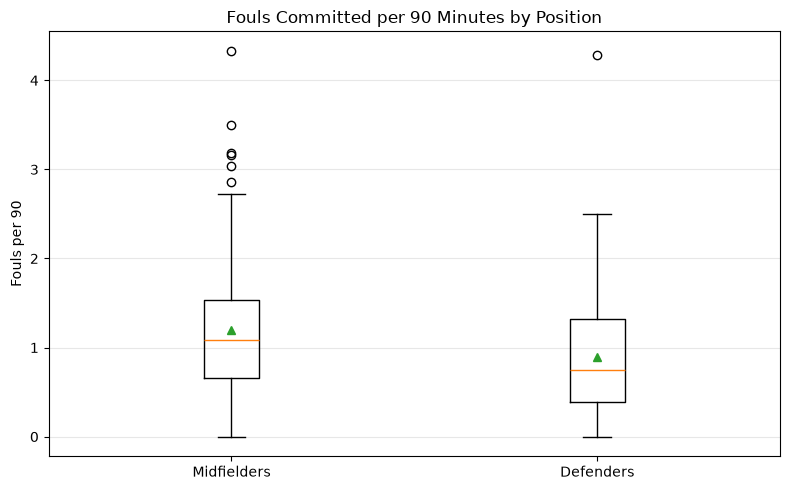

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
vals = [
    task3_sample.loc[task3_sample["PrimaryPos"] == "MF", "FoulsPer90"],
    task3_sample.loc[task3_sample["PrimaryPos"] == "DF", "FoulsPer90"]
]
ax.boxplot(vals, tick_labels=["Midfielders", "Defenders"], showmeans=True)
ax.set_title("Fouls Committed per 90 Minutes by Position")
ax.set_ylabel("Fouls per 90")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("task3_boxplot.png", dpi=200)
plt.show()

## 10. Interpretation and limitation

Interpret the mean difference, confidence interval and Welch t-test in football terms.

**Limitation:** fouls per 90 reflect tactical roles, pressing responsibilities and game context; they should not be interpreted as a direct measure of poor discipline.